In [1]:
import torch
from torch.utils.data import DataLoader
from src.datasets.mos2_sef_surrogate import MOS2SefOLDERSurrogateDataset
from src.models.our_method.older_surrogate import MultiHeadOLDERSurrogate

weights_fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/e. surrogate standalone train-runs/2025-02-17/2025-02-17_16-10-44_BB-VGG-19-Trainable-Optimal-4-Features/BB-VGG-19-Trainable-Optimal-4-Features_best_older_surrogate.pth"
model: MultiHeadOLDERSurrogate = torch.load(weights_fp).cuda()

/tmp/ipykernel_374187/2593202819.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: MultiHeadOLDERSurrogate = torch.load(weights_fp).cuda()


In [2]:
x = torch.rand((1, 128, 128)).float().cuda()
with torch.no_grad(): x = model(x); print(x)

tensor([[-1.8714, -0.8921, -0.6699, -0.5316]], device='cuda:0')


In [15]:
NUM_ITERS = 5000

test_dataset = MOS2SefOLDERSurrogateDataset("val", steps_per_epoch=NUM_ITERS)
test_dataset.normalize()
dataloader = DataLoader(test_dataset)

Calculating global mean/stds..: 100%|██████████| 1000/1000 [00:28<00:00, 34.75it/s]


In [16]:
from src.util.celano_lab_scripts import process_image

In [17]:
from tqdm import tqdm

KEYS = [
    "average_surface_current",
    "coverage_percentage",
    "num_extended_shapes",
    "total_area_extended_shapes",
]

gts = {key: [] for key in KEYS}
preds = {key: [] for key in KEYS}

for idx, item in tqdm(enumerate(dataloader), total=NUM_ITERS):

    input_tensor = item["y"].cuda()
    target = item["target"]
    prediction = model(input_tensor)

    for i, key in enumerate(KEYS):
        gt_value = target[0, i].item()          # Assumes batch size is at least 1
        pred_value = prediction[0, i].item()    # Same assumption as above
        gts[key].append(gt_value)
        preds[key].append(pred_value)
        
    if idx >= NUM_ITERS:
        break


100%|██████████| 5000/5000 [18:42<00:00,  4.46it/s]


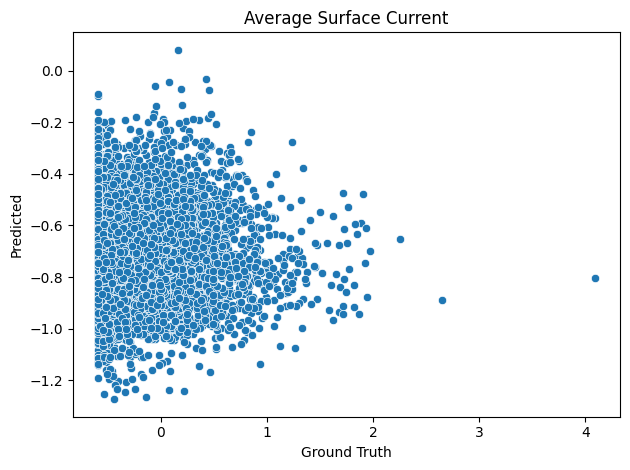

In [18]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn

I = 3
seaborn.scatterplot(
    x=gts[list(gts.keys())[I]], 
    y=preds[list(preds.keys())[I]],
    );

plt.title("Average Surface Current")
plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show();

# **Surrogate Model Performance**: Scatter Plot
---